# Exploratory Data Analysis

Exploring the tabular regression dataset with 53 anonymized features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Data

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("hidden_test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()

Train shape: (90000, 54)
Test shape: (10000, 53)


,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,target
0,236,488,16,221,382,97,-4.472136,0.107472,0,132,...,13.340874,0.870542,1.962937,7.466666,11.547794,8.822916,9.046424,7.895535,11.010677,20.107472
1,386,206,357,232,1,198,7.810250,0.763713,1,143,...,12.484882,7.168680,2.885415,12.413973,10.260494,10.091351,9.270888,3.173994,13.921871,61.763713
2,429,49,481,111,111,146,8.602325,0.651162,1,430,...,14.030257,0.394970,8.160625,12.592059,8.937577,2.265191,11.255721,12.794841,12.080951,74.651162
3,414,350,481,370,208,158,8.306624,0.424645,1,340,...,2.789577,6.416708,10.549814,11.456437,6.468099,2.519049,0.258284,9.317696,5.383098,69.424645
4,318,359,20,218,317,301,8.124038,0.767304,1,212,...,1.886560,1.919999,2.268203,0.149421,4.105907,10.416291,6.816217,8.586960,4.512419,66.767304


## 2. Basic Statistics

In [3]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
0,90000.0,249.423944,144.336393,0.000000,125.000000,250.000000,374.000000,499.000000
1,90000.0,250.236267,144.022200,0.000000,126.000000,251.000000,375.000000,499.000000
2,90000.0,248.637289,144.107577,0.000000,124.000000,248.000000,374.000000,499.000000
3,90000.0,249.736600,144.284945,0.000000,125.000000,250.000000,375.000000,499.000000
4,90000.0,249.436178,143.941581,0.000000,125.000000,250.000000,373.000000,499.000000
5,90000.0,249.656167,144.329168,0.000000,124.000000,250.000000,374.000000,499.000000
6,90000.0,-0.011402,7.038171,-9.949874,-7.071068,0.000000,7.000000,9.949874
7,90000.0,0.498548,0.288682,0.000014,0.248932,0.497136,0.747513,0.999987
8,90000.0,0.499189,0.500002,0.000000,0.000000,0.000000,1.000000,1.000000
9,90000.0,249.842033,144.612718,0.000000,124.000000,250.000000,376.000000,499.000000


In [4]:
# Data types and missing values
info_df = pd.DataFrame({
    "dtype": train.dtypes,
    "missing": train.isnull().sum(),
    "missing_pct": train.isnull().mean() * 100,
    "unique": train.nunique()
})
print(f"Total missing values: {train.isnull().sum().sum()}")
info_df

Total missing values: 0


,dtype,missing,missing_pct,unique
0,int64,0,0.0,500
1,int64,0,0.0,500
2,int64,0,0.0,500
3,int64,0,0.0,500
4,int64,0,0.0,500
5,int64,0,0.0,500
6,float64,0,0.0,199
7,float64,0,0.0,90000
8,int64,0,0.0,2
9,int64,0,0.0,500


## 3. Target Distribution

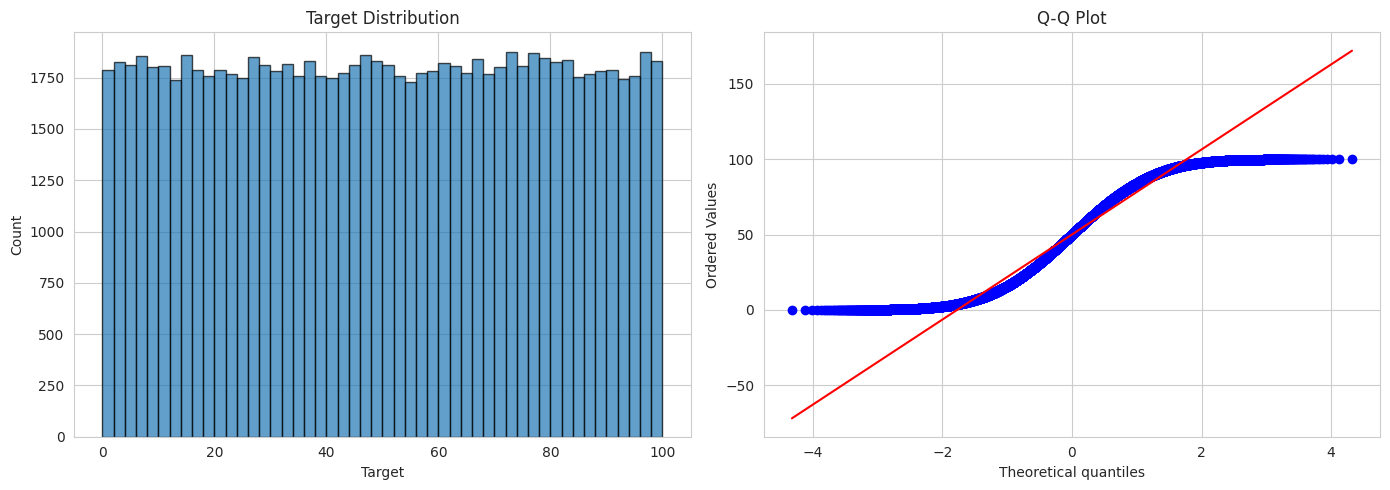

Skewness: -0.0042
Kurtosis: -1.2016


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train["target"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Count")

from scipy import stats
stats.probplot(train["target"], plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

print(f"Skewness: {train['target'].skew():.4f}")
print(f"Kurtosis: {train['target'].kurtosis():.4f}")

## 4. Feature Distributions

In [6]:
# Identify feature types by their value ranges and distributions
features = [col for col in train.columns if col != "target"]

int_features = train[features].select_dtypes(include=["int64"]).columns.tolist()
float_features = train[features].select_dtypes(include=["float64"]).columns.tolist()

print(f"Integer features ({len(int_features)}): {int_features}")
print(f"Float features ({len(float_features)}): {float_features}")

Integer features (11): ['0', '1', '2', '3', '4', '5', '8', '9', '10', '11', '12']
Float features (42): ['6', '7', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52']


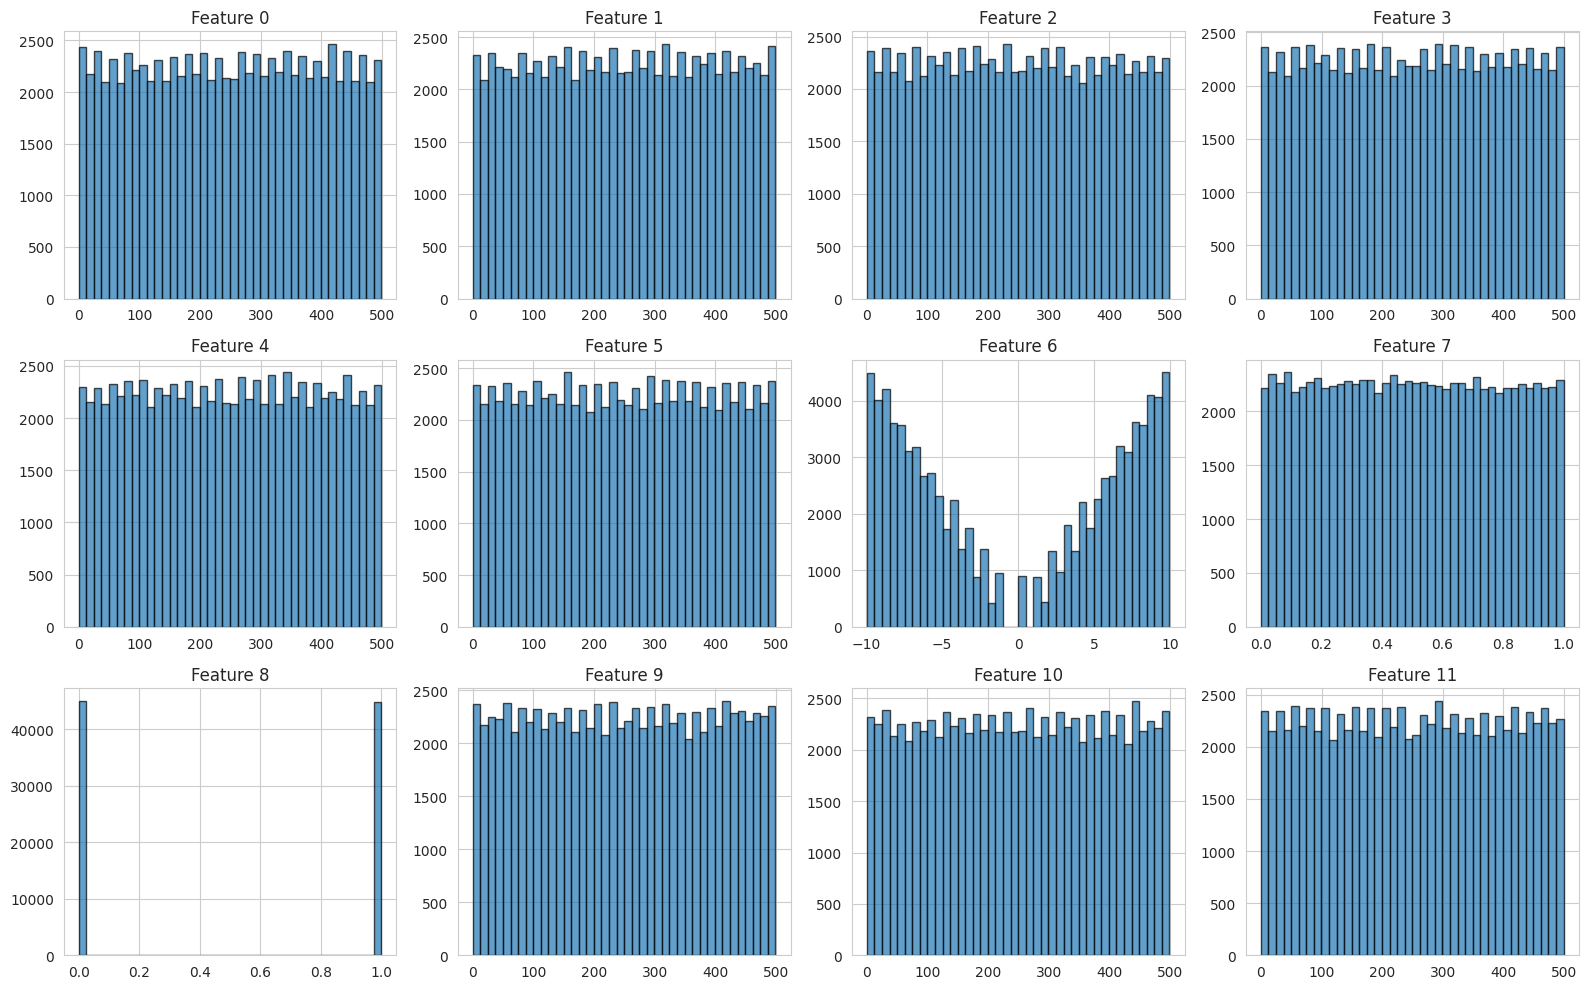

In [7]:
# Distribution of a subset of features
sample_features = features[:12]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, sample_features):
    ax.hist(train[col], bins=40, alpha=0.7, edgecolor="black")
    ax.set_title(f"Feature {col}")
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

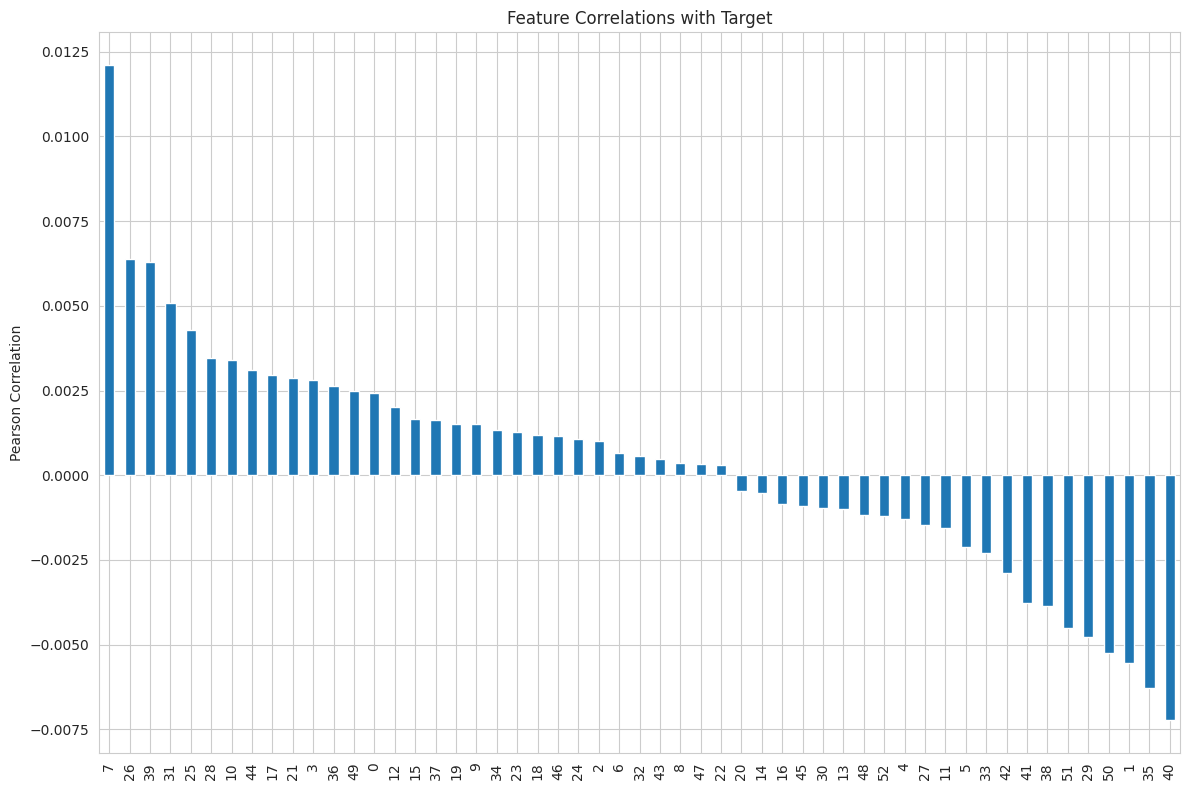

Top 10 positive correlations:
7     0.012103
26    0.006370
39    0.006283
31    0.005077
25    0.004276
28    0.003451
10    0.003396
44    0.003092
17    0.002953
21    0.002874
Name: target, dtype: float64

Top 10 negative correlations:
33   -0.002301
42   -0.002876
41   -0.003770
38   -0.003845
51   -0.004507
29   -0.004785
50   -0.005243
1    -0.005545
35   -0.006267
40   -0.007216
Name: target, dtype: float64


In [8]:
# Correlation with target
correlations = train.corr()["target"].drop("target").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
correlations.plot(kind="bar", ax=ax)
ax.set_title("Feature Correlations with Target")
ax.set_ylabel("Pearson Correlation")
plt.tight_layout()
plt.show()

print("Top 10 positive correlations:")
print(correlations.head(10))
print("\nTop 10 negative correlations:")
print(correlations.tail(10))

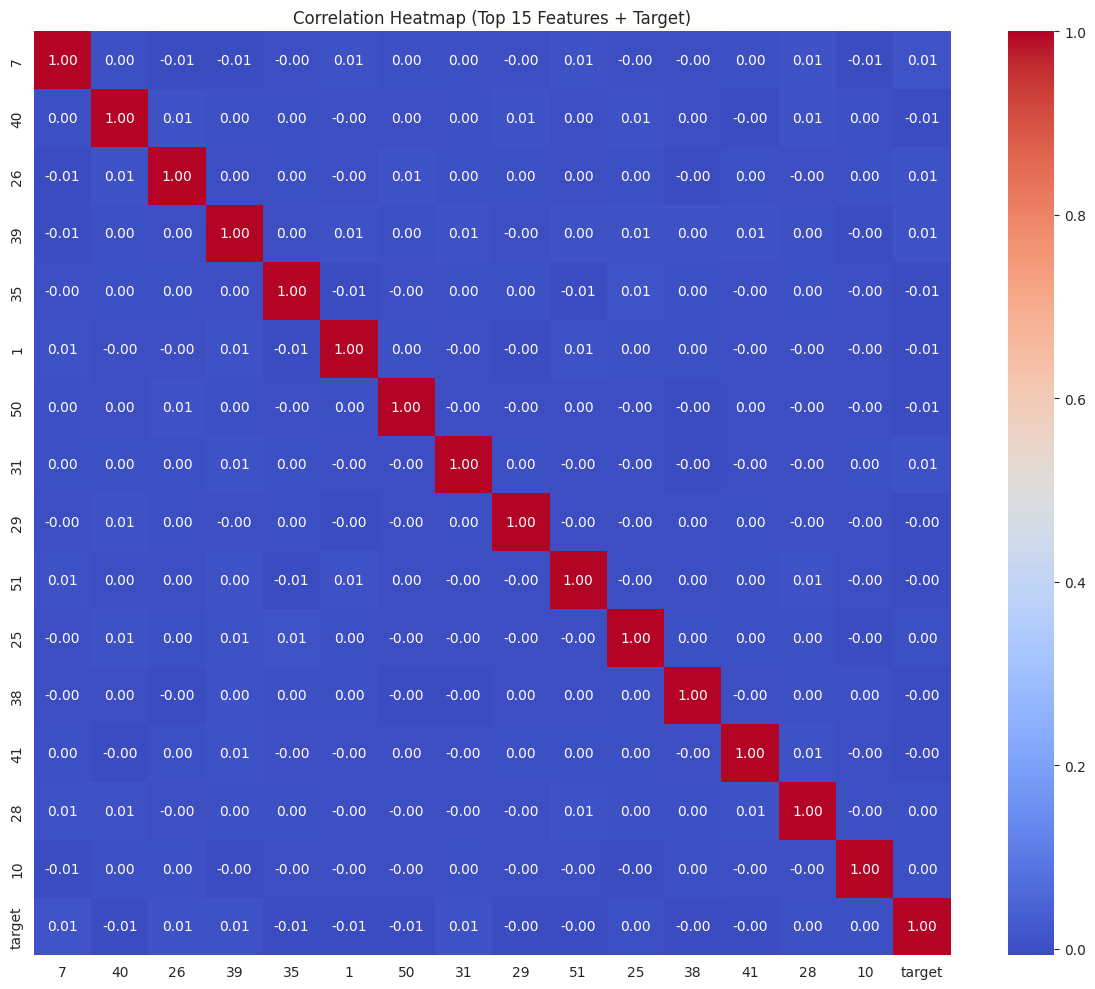

In [9]:
# Feature-feature correlation heatmap (top correlated features)
top_features = correlations.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append("target")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(train[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap (Top 15 Features + Target)")
plt.tight_layout()
plt.show()

## 6. Train vs Test Distribution Comparison

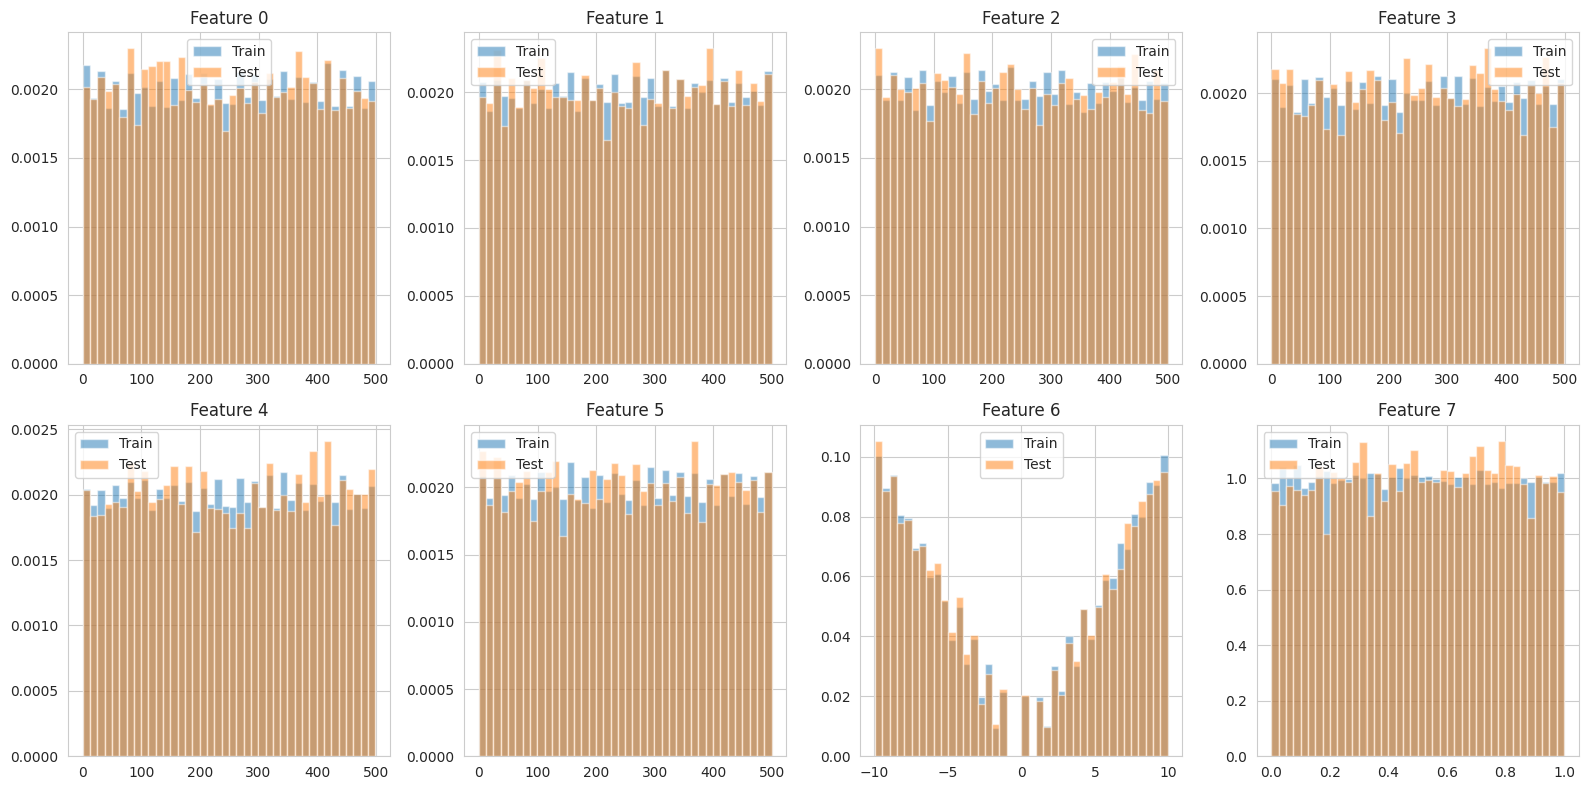

In [10]:
# Compare distributions of a few features between train and test
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, features[:8]):
    ax.hist(train[col], bins=40, alpha=0.5, label="Train", density=True)
    ax.hist(test[col], bins=40, alpha=0.5, label="Test", density=True)
    ax.set_title(f"Feature {col}")
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Summary

Key findings:
- 90,000 training samples, 10,000 test samples
- 53 anonymized features (11 integer, 42 float)
- No missing values
- Target is approximately uniformly distributed in [0, 100]
- Feature distributions appear consistent between train and test sets